In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
data= pd.read_csv('Citas_Digital_sin_nulos.csv') 

In [3]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 16 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unnamed: 0                                676 non-null    int64  
 1   BDC                                       676 non-null    str    
 2   Fecha                                     676 non-null    str    
 3   Nombre Cliente                            676 non-null    str    
 4   Telefono                                  676 non-null    str    
 5   Estatus de Lead                           676 non-null    str    
 6   Potencial de compra                       676 non-null    float64
 7   PDM                                       676 non-null    float64
 8   SDC                                       676 non-null    float64
 9   Venta                                     676 non-null    float64
 10  Asesor Asignado                           676 non

In [4]:
#Corroboramos valores nulos
valores_nulos=data.isnull().sum()
valores_nulos

Unnamed: 0                                  0
BDC                                         0
Fecha                                       0
Nombre Cliente                              0
Telefono                                    0
Estatus de Lead                             0
Potencial de compra                         0
PDM                                         0
SDC                                         0
Venta                                       0
Asesor Asignado                             0
¿Por que no ha visitado la agencia?         0
¿Por que no hay solicitud de credito?       0
¿Por que no hubo prueba de manejo ?         0
¿Por que no hubo proceso wow?               0
¿Por que se asigno antes de vistar piso?    0
dtype: int64

In [9]:
#Creo 2 dataframe para poder procesar los outliers
cuantitativas= data.iloc[ : , 6:10 ]
cualitativas = data.iloc[:, [1, 2, 3, 4, 5, 10, 11, 12, 13, 14, 15]]

<Figure size 1500x800 with 0 Axes>

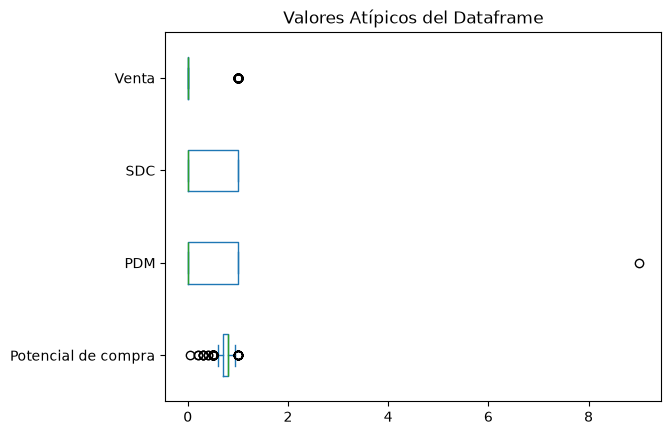

In [10]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

**PROCEDIMIENTO "DESVIACIÓN ESTÁNDAR" PARA ELIMINAR OUTLIERS EN DATAFRAME**

In [11]:
#Método aplicando desviación estandar. Encuentro los valores extremos
y=cuantitativas
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido Potencial de compra    1.097997
PDM                    2.294051
SDC                    1.867428
Venta                  0.926621
dtype: float64
Limite inferior permitido Potencial de compra    0.377003
PDM                   -1.291092
SDC                   -1.071570
Venta                 -0.755024
dtype: float64


In [12]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data2= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data2

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.40,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,NaN
4,0.90,1.0,0.0,0.0
...,...,...,...,...
671,0.80,1.0,1.0,0.0
672,0.50,0.0,0.0,0.0
673,0.50,1.0,0.0,0.0
674,1.00,1.0,1.0,NaN


In [13]:
#Corroboramos valores nulos del dataframe4
valores_nulos=data2.isnull().sum()
valores_nulos

Potencial de compra     7
PDM                     1
SDC                     0
Venta                  58
dtype: int64

In [14]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data_clean=data2.copy()
data_clean=data_clean.fillna(round(data2.mean(),1))
data_clean

,Potencial de compra,PDM,SDC,Venta
0,0.90,1.0,0.0,0.0
1,0.40,0.0,0.0,0.0
2,0.85,0.0,0.0,0.0
3,0.90,0.0,0.0,0.0
4,0.90,1.0,0.0,0.0
...,...,...,...,...
671,0.80,1.0,1.0,0.0
672,0.50,0.0,0.0,0.0
673,0.50,1.0,0.0,0.0
674,1.00,1.0,1.0,0.0


In [18]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data_clean.isnull().sum()
valores_nulos

Potencial de compra    0
PDM                    0
SDC                    0
Venta                  0
dtype: int64

In [16]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data_clean], axis=1)
Datos_limpios

,BDC,Fecha,Nombre Cliente,Telefono,Estatus de Lead,Asesor Asignado,¿Por que no ha visitado la agencia?,¿Por que no hay solicitud de credito?,¿Por que no hubo prueba de manejo ?,¿Por que no hubo proceso wow?,¿Por que se asigno antes de vistar piso?,Potencial de compra,PDM,SDC,Venta
0,Saul,2026-06-01,Guillermo,Sin teléfono,Finalizado,Nancy,"Ya visito la Agencia el dia jueves 17, intere...","Pide arrendamiento, unicamente se esta en espe...","Si, hizo prueba de manejo","Si recibio procesos wow, estuvo en la agencia ...","No, se espero a que visitara la agencia para s...",0.90,1.0,0.0,0.0
1,Saul,2026-06-01,Roberto,Sin teléfono,Finalizado,Victor,Ya visito la Agencia el dia 3 de abril,Por que primero queria manejar las unidad,No habia unidad GS8 HEV para prueba de manejo,"Si recibio procesos wow, sin embargo no quizo ...",Se asigno hasta que visitara Piso,0.40,0.0,0.0,0.0
2,Saul,2026-06-01,Irving,Sin teléfono,Finalizado,Alan,Ya visito la agencia el dia 21 de abril,"Firmo solicitud, sin embargo despues comento q...",Por que no habia unidad para prueba de manejo,"Si se realizo el proceso wow, los clientes se ...",Se asigno hasta que visitara Piso,0.85,0.0,0.0,0.0
3,Saul,2026-06-01,Oswaldo,Sin teléfono,Venta,Mauricio,El cliente vive en Tabasco Villahermosa,Sera compra de contado,"Ya la manejo en Villahermosa, sin embargo por ...","Las veces que se le ha marcado, agradece mucho...","Necesitabamos sacar el apartado, por eso se as...",0.90,0.0,0.0,0.0
4,Saul,2026-06-01,Rodrigo,Sin teléfono,Finalizado,Mauricio,"Visito la agencia el mes pasado, y nos visita ...",Hoy visita nuevamente la agencia y se firma so...,"La primera vez que nos visito, realizo PDM",Si recibio el proceso wow la primera vez que n...,Se asigno hasta que visitara Piso la primera ...,0.90,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,Ana,2026-07-22,Maira Escalante,Sin teléfono,Activo,Pedro Antonio,Ya visito la agencia,depende del padres,Ya realizo prueba de manejo,Recibio la atencion,Se asigno en la visita,0.80,1.0,1.0,0.0
672,Ignacio,2026-07-22,Zaira Macip,Sin teléfono,Activo,Aurelio,Ya visito la agencia,depende del padres,Ya realizo prueba de manejo,Recibio la atencion,Se asigno en la visita,0.50,0.0,0.0,0.0
673,Ignacio,2026-07-27,Julio Hernandez,Sin teléfono,Activo,Victor,Ya visito la agencia,depende del padres,Ya realizo prueba de manejo,Recibio la atencion,Se asigno en la visita,0.50,1.0,0.0,0.0
674,Ignacio,2026-07-24,Xhunaxhi Vicente,Sin teléfono,Activo,Ignacio,Ya visito la agencia,depende del padres,Ya realizo prueba de manejo,Recibio la atencion,Se asigno en la visita,1.00,1.0,1.0,0.0


In [17]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

BDC                                         0
Fecha                                       0
Nombre Cliente                              0
Telefono                                    0
Estatus de Lead                             0
Asesor Asignado                             0
¿Por que no ha visitado la agencia?         0
¿Por que no hay solicitud de credito?       0
¿Por que no hubo prueba de manejo ?         0
¿Por que no hubo proceso wow?               0
¿Por que se asigno antes de vistar piso?    0
Potencial de compra                         0
PDM                                         0
SDC                                         0
Venta                                       0
dtype: int64

In [19]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Citas_Digital_sin_valores_atipicos.csv")